# Notebook to Pre Process the data

#### Imports
#### For functions used to filter the questions see 'question_filtering.py'

In [1]:
import importlib
import pandas as pd
import numpy as np
import question_filtering

importlib.reload(question_filtering)

<module 'question_filtering' from 'C:\\Users\\Minh\\Desktop\\Psycho Arbeit\\Psycho_DataspellProjekt\\question_filtering.py'>

### Decode the questions 

Due to the CSV-file using encodings for the questions (columns), it is necessary to decode them for readability
Meaning changing the column names for example from 'Y11_Q33a' to 'Direct contact with children' in order to filter the question later on

In [2]:
# Change to True if you want to do the conversion/decoding
do_decoding = False

# Read csv file with the 2011 data
data = pd.read_csv('data/eqls_2011.csv')
data.count()

# Load decoding file
grid = pd.read_csv('data/eqls_concordance_grid_bearbeitbar.csv', sep=';')
grid.to_csv('data/grid_cleaned.csv', index=False)

# Map the columns of the dataframe to the explanation on the Excel table
column_mapping = dict(zip(grid.iloc[:, 0], grid.iloc[:, 1]))

# Rname the columns accordingly
data = data.rename(columns=column_mapping)

# Save dataframe to new file
if do_decoding:
    data.to_csv('data/eqls_2011_decoded.csv', index=False)

### Filtering Questions used to predict happiness

There are 199 questions that could be used as features, but not all are relevant and should be removed
e.g. columns that contain IDs or columns that have too many missing values(rows)

In [3]:
# Load file
decoded_df = pd.read_csv('data/eqls_2011_decoded_converted.csv')
# Deleting the columns that are missing >40% of data
high_missing40 = decoded_df.columns[decoded_df.isna().mean() > 0.4]
print(high_missing40)
decoded_df = decoded_df.drop(columns=high_missing40)
print(decoded_df.shape)

# Display the columns where data is missing
missing_percentage = decoded_df.isna().mean() * 100
# Filter columns where rows are missing values
high_missing = missing_percentage[missing_percentage > 2]
print(high_missing)
print(decoded_df.shape)

Index(['Limited by chronic health problems?',
       'How much time spent on travelling to work/study?',
       'Difficult to use child care because of cost?',
       'Difficult to use child care because of availability?',
       'Difficult to use child care because of access?',
       'Difficult to use child care because of quality of care?',
       'Difficult to use long term care because of cost?',
       'Difficult to use long term care because of availability?',
       'Difficult to use long term care because of access?',
       'Difficult to use long term care because of quality of care?',
       'How satisfied with present job?',
       'How many hours work per week in 1st job?',
       'How many hours does your partner work per week?',
       'How many hours per week would you prefer your partner to work?',
       'Working hours fit with family/social commitments?',
       'Come home from work too tired to do some of the household jobs',
       'Difficult to fulfil family respo

#### Manual removal/manipulation of certain columns/questions
##### Lists of removed question in 'question_filtering.py'

In [22]:
use_strict_filter = False

if use_strict_filter:
    filtered_df = question_filtering.strict_question_filtering(decoded_df)
    file_name = 'data/data_eqls_STRICT_filtered.csv'
else:
    filtered_df = question_filtering.loose_question_filtering(decoded_df)
    file_name = 'data/data_eqls_LOOSE_filtered.csv'

(43636, 168)


#### Removing all rows that are missing ANY values to have a complete dataframe and convert the values to integers 

In [23]:
# Removing all ROWS that are missing ANY values in order to have a clean dataframe
missing_percentage = filtered_df.isna().mean() * 100
missing = missing_percentage[missing_percentage > 0]
cleaned_df = filtered_df.dropna(subset=missing.index)
print("Shape:")
print(cleaned_df.shape)

# Check if alle NAs are filled
# Display the columns where data is missing
missing_percentage = cleaned_df.isna().mean() * 100
any_missing = missing_percentage[missing_percentage > 0]
print("Columns that have NANs:")
print(any_missing)

# Converting the values to integers
df = cleaned_df.copy()
for column in df.select_dtypes(include=["float64", "float32"]).columns:
    non_na_values = df[column].dropna().unique()

    # Prüfe, ob alle Werte ganzzahlig sind oder höchstens eine Nachkommastelle haben
    if np.all(np.mod(non_na_values, 1) == 0) or np.all(np.isclose(non_na_values, np.round(non_na_values), atol=0.1)):
        df[column] = df[column].astype(pd.Int64Dtype())  # Erlaubt NaNs

print(df.shape)
df.to_csv(file_name, index=False)

Shape:
(6122, 168)
Columns that have NANs:
Series([], dtype: float64)
(6122, 168)


### Descriptive Plots of the Data

In [8]:
import matplotlib.pyplot as plt

data = pd.read_csv('data/data_eqls_LOOSE_filtered.csv')

count    6122.000000
mean        7.665632
std         1.757405
min         1.000000
25%         7.000000
50%         8.000000
75%         9.000000
max        10.000000
Name: How happy are you?, dtype: float64


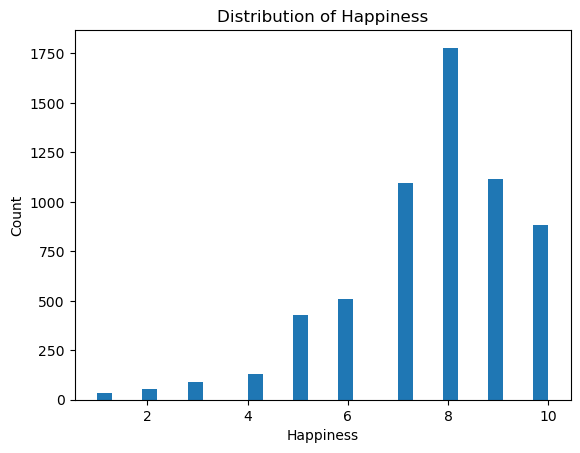

How happy are you?
1       35
2       53
3       89
4      132
5      427
6      509
7     1097
8     1779
9     1117
10     884
Name: count, dtype: int64
How happy are you?
1      0.571709
2      0.865730
3      1.453773
4      2.156158
5      6.974845
6      8.314276
7     17.918981
8     29.059131
9     18.245671
10    14.439726
Name: proportion, dtype: float64


In [32]:
# Target
target = 'How happy are you?'

# Basic statistics
print(data[target].describe())

# Histogramm
plt.figure()
plt.hist(data[target].dropna(), bins=30)
plt.xlabel('Happiness')
plt.ylabel('Count')
plt.title('Distribution of Happiness')
plt.show()
counts = data[target].value_counts().sort_index()
print(counts)
percent = data[target].value_counts(normalize=True).sort_index() * 100
print(percent)


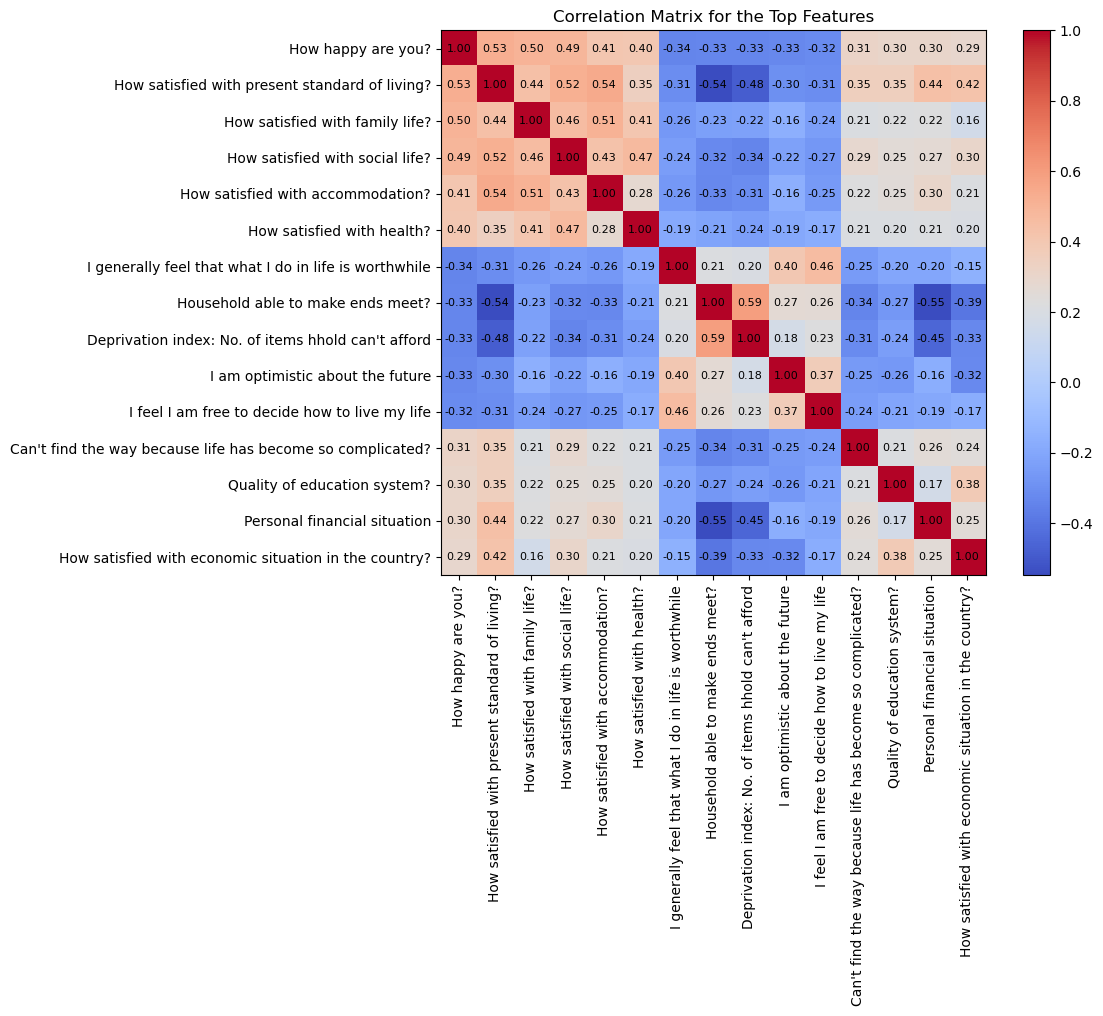

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Correlation Matrix
target = "How happy are you?"
corr_target = data.corr(numeric_only=True)[target]
top_features = corr_target.abs().sort_values(ascending=False).iloc[1:15].index.tolist()

# Target
top_features = [target] + top_features
# Matrix
corr_matrix = data[top_features].corr()

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
plt.colorbar(cax)

ax.set_xticks(range(len(top_features)))
ax.set_yticks(range(len(top_features)))
ax.set_xticklabels(top_features, rotation=90)
ax.set_yticklabels(top_features)

ax.xaxis.set_ticks_position('bottom')

# Values
for i in range(len(top_features)):
    for j in range(len(top_features)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", va='center', ha='center', fontsize=8)

plt.title('Correlation Matrix for the Top Features')
plt.tight_layout()
plt.show()

In [36]:
target_corr = corr_matrix[target].sort_values(ascending=False)

print("\nCorrelations with 'How happy are you?':\n")
print(target_corr)


Correlations with 'How happy are you?':

How happy are you?                                            1.000000
How satisfied with present standard of living?                0.527028
How satisfied with family life?                               0.498466
How satisfied with social life?                               0.490638
How satisfied with accommodation?                             0.405214
How satisfied with health?                                    0.399858
Can't find the way because life has become so complicated?    0.314866
Quality of education system?                                  0.303851
Personal financial situation                                  0.301430
How satisfied with economic situation in the country?         0.289999
I feel I am free to decide how to live my life               -0.316574
I am optimistic about the future                             -0.325420
Deprivation index: No. of items hhold can't afford           -0.333609
Household able to make ends meet?  